In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dfg= pd.read_csv('/content/2024pg.csv')

dfg['Harvestdate']= pd.to_datetime(dfg['Harvestdate'])
dfg['Sowdate']= pd.to_datetime(dfg['Sowdate'])


agrod= dfg.iloc[:,:23]
soild= dfg.iloc[:,23:40]
weatherd= dfg.iloc[:,40:]
agrod.head(15)



for i in dfg.columns:
  if i.endswith('x'): # Corrected: Use standard string method .endswith()
    print(i)

23 Index(['Country', 'Id', 'Awareness', 'Latitude', 'Longitude', 'Region', 'Crop',
       'Color', 'Tillage', 'Biocide', 'Fertilizer', 'Seedprep', 'Sowmethod',
       'Prevtime', 'Prevcrop', 'Fum', 'Ota', 'Zen', 'Don', 'Harvestdate',
       'Sowdate', 'Afla', 'Cultdays'],
      dtype='object')
17 Index(['ph', 'carbon_organic', 'carbon_total', 'nitrogen_total',
       'cation_exchange_capacity', 'phosphorous_extractable',
       'potassium_extractable', 'calcium_extractable', 'magnesium_extractable',
       'iron_extractable', 'zinc_extractable', 'sulphur_extractable',
       'sand_content', 'silt_content', 'clay_content', 'stone_content',
       'bulk_density'],
      dtype='object')


376

Index(['T2M_s1', 'PRECTOTCORR_s1', 'RH2M_s1', 'ALLSKY_SFC_SW_DWN_s1', 'T2M_s2',
       'PRECTOTCORR_s2', 'RH2M_s2', 'ALLSKY_SFC_SW_DWN_s2', 'T2M_s3',
       'PRECTOTCORR_s3',
       ...
       'RH2M_g28', 'ALLSKY_SFC_SW_DWN_g28', 'T2M_g29', 'PRECTOTCORR_g29',
       'RH2M_g29', 'ALLSKY_SFC_SW_DWN_g29', 'T2M_g30', 'PRECTOTCORR_g30',
       'RH2M_g30', 'ALLSKY_SFC_SW_DWN_g30'],
      dtype='object', length=376)

<Axes: xlabel='Crop', ylabel='Afla'>

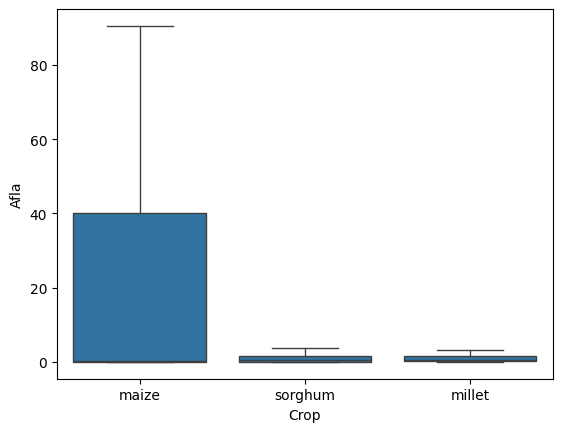

In [2]:
print(len(agrod.columns),agrod.columns)
print(len(soild.columns),soild.columns)
display(len(weatherd.columns),weatherd.columns)

sns.boxplot(x='Crop', y='Afla', data=dfg, showfliers=False)

In [ ]:
dfg.columns
print(len(dfg))
dfg['Afla'].describe()

602


,Afla
count,602.000000
mean,108.448505
std,360.352611
min,0.000000
25%,0.100000
50%,0.400000
75%,3.275000
max,2690.000000


In [ ]:
pip install imblearn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


dfg= pd.read_csv('/content/2024pg.csv')

dfg['Harvestdate']= pd.to_datetime(dfg['Harvestdate'])
dfg['Sowdate']= pd.to_datetime(dfg['Sowdate'])

#data
maized = dfg[dfg['Crop'].str.lower() == 'maize']

#maized['Afla'] = np.where(maized['Afla'] >90, 90, maized['Afla'])
#dfg['Afla'] = dfg['Afla'].clip(upper=400)

y = np.where(dfg['Fum'] >4000, 1, 0) # Changed 'positive' to 1 and 'negative' to 0
#
#y= dfg['Afla_c']
x = dfg.iloc[:,23:]
x= x.astype(float)

print(x.columns)
print(x.shape)
# split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(np.unique_counts(y_train))

# smote
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

print(f'Resampled dataset shape {np.unique(y_train_res, return_counts=True)}')
x_train= x_train_res
y_train= y_train_res
#scale
scaler= StandardScaler()
scaler.fit(x_train)
x_train= scaler.transform(x_train)
x_test= scaler.transform(x_test)

Index(['ph', 'carbon_organic', 'carbon_total', 'nitrogen_total',
       'cation_exchange_capacity', 'phosphorous_extractable',
       'potassium_extractable', 'calcium_extractable', 'magnesium_extractable',
       'iron_extractable',
       ...
       'RH2M_g28', 'ALLSKY_SFC_SW_DWN_g28', 'T2M_g29', 'PRECTOTCORR_g29',
       'RH2M_g29', 'ALLSKY_SFC_SW_DWN_g29', 'T2M_g30', 'PRECTOTCORR_g30',
       'RH2M_g30', 'ALLSKY_SFC_SW_DWN_g30'],
      dtype='object', length=393)
(602, 393)
UniqueCountsResult(values=array([0, 1]), counts=array([422,  59]))
Resampled dataset shape (array([0, 1]), array([422, 422]))


<Axes: xlabel='Fum', ylabel='Count'>

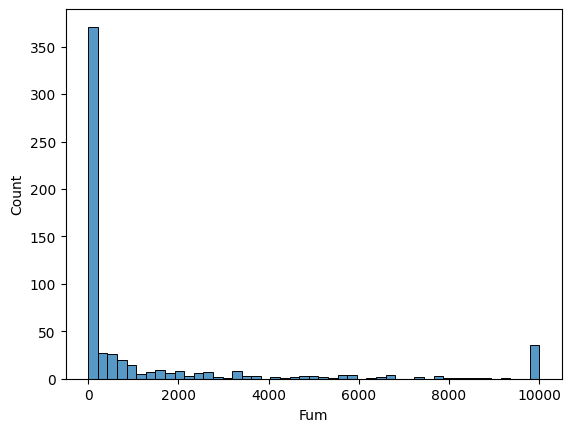

In [ ]:
sns.histplot(dfg['Fum'].clip(upper=10000))

In [ ]:
# value counts
np.unique_counts(y)
np.unique(y_train, return_counts=True)

(array([0, 1]), array([392, 392]))

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler

# Lasso Classification (as it was originally implemented for classification, but uses Lasso)
# Keeping this function as is, as the plan asks to *define* a new Lasso Regression function, not modify this classification one.
def train_Lcmodel(x_train, y_train, x_test, y_test):
    """Trains and evaluates a Lasso model for classification (with binary conversion)."""
    #modeling
    lmodel= Lasso(max_iter=100000) # Increased max_iter to help with convergence
    param_grid= {'alpha':[0.1,1,0.001,0.01]}
    lcv= GridSearchCV(lmodel, param_grid, cv=5)
    lcv.fit(x_train, y_train)
    lcvmodel= lcv.best_estimator_

    # Convert continuous predictions to binary (0 or 1) using a threshold of 0.5
    y_train_pred_binary = (lcvmodel.predict(x_train) > 0.5).astype(int)
    lpred = (lcvmodel.predict(x_test) > 0.5).astype(int)

    #results
    print("Lasso Model Results (Classification):")
    print(f"Best Parameters: {lcv.best_params_}")
    print(f"Train accuracy Score: {accuracy_score(y_train, y_train_pred_binary)}")

    lacc= accuracy_score(y_test, lpred)
    lprec= precision_score(y_test, lpred, zero_division=0) # Added zero_division to handle cases with no positive predictions
    lf1 = f1_score(y_test, lpred, zero_division=0)
    lrecall = recall_score(y_test, lpred, zero_division=0)

    print(pd.DataFrame({'Actual':y_test, 'Predicted':lpred}))

    return lcvmodel, lpred, {'Accuracy': lacc, 'Precision': lprec, 'F1': lf1, 'Recall': lrecall}


# random forests (classification)

def train_Rcmodel(x_train, y_train, x_test, y_test):
    """Trains and evaluates a Random Forest classification model."""
    #modeling
    Rmodel = RandomForestClassifier(random_state=41)
    param_gridR = {'n_estimators': [10, 15, 25, 20], 'min_samples_split': [2], 'max_depth': [25, 10, 15]}
    Rcv = GridSearchCV(Rmodel, param_gridR, cv=5)
    Rcv.fit(x_train, y_train)
    Rcvmodel = Rcv.best_estimator_

    #results
    print("Random Forest Model Results:")
    print(f"Best Parameters: {Rcv.best_params_}")
    print(f"Train accuracy Score: {accuracy_score(y_train, Rcvmodel.predict(x_train))}")

    Rpred = Rcvmodel.predict(x_test)
    Racc= accuracy_score(y_test, Rpred)
    Rprec= precision_score(y_test, Rpred, zero_division=0)
    Rf1 = f1_score(y_test, Rpred, zero_division=0)
    Rrecall = recall_score(y_test, Rpred, zero_division=0)

    print(pd.DataFrame({'Actual':y_test, 'Predicted':Rpred}))

    return Rcvmodel, Rpred, {'Accuracy': Racc, 'Precision': Rprec, 'F1': Rf1, 'Recall': Rrecall}


# Corrected Gradient Boosting Classifier
def train_Gcmodel(x_train, y_train, x_test, y_test):
    """Trains and evaluates a Gradient Boosting classification model."""
    #modeling
    Gmodel = GradientBoostingClassifier(random_state=41) # Corrected to GradientBoostingClassifier
    param_gridG = {'n_estimators': [10, 15, 25, 20], 'min_samples_split': [2], 'max_depth': [3, 5, 7]} # Adjusted max_depth for GBC
    Gcv = GridSearchCV(Gmodel, param_gridG, cv=5)
    Gcv.fit(x_train, y_train)
    Gcvmodel = Gcv.best_estimator_

    #results
    print("Gradient Boosting Classification Model Results:")
    print(f"Best Parameters: {Gcv.best_params_}")
    print(f"Train accuracy Score: {accuracy_score(y_train, Gcvmodel.predict(x_train))}")

    Gpred = Gcvmodel.predict(x_test)
    Gacc= accuracy_score(y_test, Gpred)
    Gprec= precision_score(y_test, Gpred, zero_division=0)
    Gf1 = f1_score(y_test, Gpred, zero_division=0)
    Grecall = recall_score(y_test, Gpred, zero_division=0)

    print(pd.DataFrame({'Actual':y_test, 'Predicted':Gpred}))

    return Gcvmodel, Gpred, {'Accuracy': Gacc, 'Precision': Gprec, 'F1': Gf1, 'Recall': Grecall}

# New Lasso Regression Function
def train_Lrmodel(x_train, y_train, x_test, y_test):
    """Trains and evaluates a Lasso regression model."""
    #modeling
    lmodel = Lasso(random_state=42, max_iter=100000) # Increased max_iter for regression as well
    param_grid = {'alpha': [0.1, 1.0, 0.01, 0.001]}
    lcv = GridSearchCV(lmodel, param_grid, cv=5, scoring='neg_mean_squared_error')
    lcv.fit(x_train, y_train)
    lcvmodel = lcv.best_estimator_

    #results
    print("Lasso Regression Model Results:")
    print(f"Best Parameters: {lcv.best_params_}")
    print(f"Train R2 Score: {lcvmodel.score(x_train, y_train)}")

    lpred = lcvmodel.predict(x_test)
    lmse = mean_squared_error(y_test, lpred)
    lr2 = r2_score(y_test, lpred)
    lmae = mean_absolute_error(y_test, lpred)
    lrmse = root_mean_squared_error(y_test, lpred)

    print(f"MSE: {lmse}")
    print(f"R2_SCORE: {lr2}")
    print(f"MAE: {lmae}")
    print(f"RMSE: {lrmse}")

    print(pd.DataFrame({'Actual':y_test, 'Predicted':lpred}))

    return lcvmodel, lpred, {'MSE': lmse, 'R2_SCORE': lr2, 'MAE': lmae, 'RMSE': lrmse}


# create and save a radar plot (This function remains unchanged)

def create_and_save_radar_plot(df_metrics, plot_title):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # Use metrics directly (no normalization)
    metrics = ['Accuracy', 'Precision', 'F1', 'Recall']

    # Set Model as index
    df_plot = df_metrics.set_index('Model')

    print("Raw Classification Metrics for Radar Plot:")
    display(df_plot)

    num_vars = len(metrics)

    # Angles for radar
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(1, len(df_plot), figsize=(6 * len(df_plot), 6), subplot_kw=dict(polar=True))

    # Handle case with only 1 model
    if len(df_plot) == 1:
        axes = [axes]

    for i, model_name in enumerate(df_plot.index):
        ax = axes[i]

        values = df_plot.loc[model_name, metrics].tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=1, linestyle='solid', label=model_name)
        ax.fill(angles, values, alpha=0.25)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)

        # IMPORTANT: dynamic scaling (no fixed 0–1 anymore)
        max_val = max(values)
        ax.set_ylim(0, max_val * 1.1)

        ax.set_title(f'{model_name} Model Performance', size=12, y=1.1)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.suptitle(plot_title, y=1.05, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('radar_plots.png')
    plt.show()

    print("Radar plot created using raw (non-normalized) values.")


Lasso Model Results (Classification):
Best Parameters: {'alpha': 0.01}
Train accuracy Score: 0.8779620853080569
     Actual  Predicted
0         0          0
1         0          1
2         0          0
3         0          0
4         0          1
..      ...        ...
116       0          0
117       1          1
118       0          0
119       0          0
120       0          0

[121 rows x 2 columns]
Model 1: lasso completed running
Random Forest Model Results:
Best Parameters: {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 20}
Train accuracy Score: 0.9443127962085308
     Actual  Predicted
0         0          0
1         0          1
2         0          0
3         0          0
4         0          1
..      ...        ...
116       0          0
117       1          1
118       0          0
119       0          0
120       0          0

[121 rows x 2 columns]
Model 2: rf completed running
Gradient Boosting Classification Model Results:
Best Parameters: {'max_depth

,Accuracy,Precision,F1,Recall
Model,,,,
lasso,0.818182,0.428571,0.576923,0.882353
rf,0.884298,0.565217,0.650000,0.764706
gbm,0.867769,0.520000,0.619048,0.764706


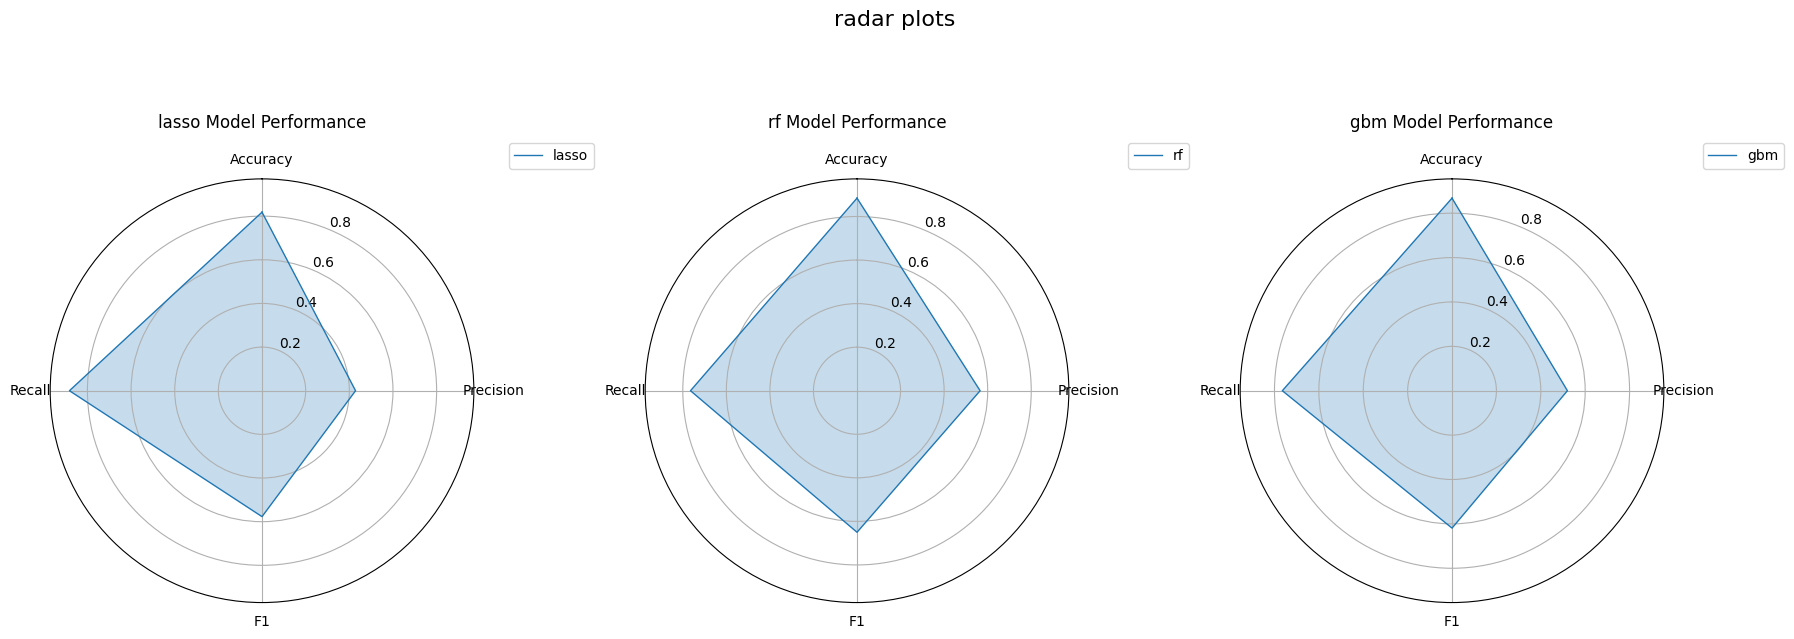

Radar plot created using raw (non-normalized) values.


In [ ]:
#CLASSIFICATION script
models_eval = {'lasso' : train_Lcmodel, 'rf': train_Rcmodel, 'gbm': train_Gcmodel}
model_results = {}

# Run all models and store their results
for i, j in enumerate(models_eval):
    train_model = models_eval[j]
    model_name = j
    model_result = train_model(x_train, y_train, x_test, y_test)
    model_results[model_name] = model_result
    print(f"Model {i+1}: {model_name} completed running")
    print("="*50)

# After all models have run, collect and display the metrics in a DataFrame

classification_metrics_summary = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'F1': [],
    'Recall': []
}

for model_name, result in model_results.items():
    metrics = result[2] # The metrics dictionary is the third element in the tuple
    # predictions = result[1] # Not directly used for summary table here
    classification_metrics_summary['Model'].append(model_name)
    classification_metrics_summary['Accuracy'].append(metrics['Accuracy'])
    classification_metrics_summary['Precision'].append(metrics['Precision'])
    classification_metrics_summary['F1'].append(metrics['F1'])
    classification_metrics_summary['Recall'].append(metrics['Recall'])


df_summary = pd.DataFrame(classification_metrics_summary)
print("\n===== Model Performance Summary =====")
print(df_summary)
print(pd.DataFrame({'Actual':y_test, 'lasso_Pred':model_results['lasso'][1], "rf_pred": model_results['rf'][1], 'gbm':model_results['gbm'][1]}))
print("=====================================")
create_and_save_radar_plot(df_summary, 'radar plots')

In [ ]:
# data_preparation.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load the dataset
dfg = pd.read_csv('/content/2024pg.csv')

# Convert dates
dfg['Harvestdate'] = pd.to_datetime(dfg['Harvestdate'])
dfg['Sowdate'] = pd.to_datetime(dfg['Sowdate'])

# Define targets and thresholds
targets = {
    'Afla': 10,
    'Fum': 4000
}

# Clip targets at maximum thresholds
for target, threshold in targets.items():
    dfg[target] = dfg[target].clip(upper=threshold)

# Features
x = dfg.iloc[:, 23:].astype(float)  # adjust columns if needed

# Scale features
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

# Save processed data for later use
np.save('x_scaled.npy', x_scaled)
dfg.to_csv('dfg_processed.csv', index=False)

# Function to generate train/test splits for a given target
def prepare_target(y_column, x_scaled):
    y = np.where(dfg[y_column] >= targets[y_column], 1, 0)
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y, test_size=0.2, random_state=42
    )

    # Handle imbalance using SMOTE
    sm = SMOTE(random_state=42)
    x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

    # Scale again after resampling
    scaler = StandardScaler()
    scaler.fit(x_train_res)
    x_train_res = scaler.transform(x_train_res)
    x_test_scaled = scaler.transform(x_test)

    return x_train_res, x_test_scaled, y_train_res, y_test

# Example usage:
# x_train_afla, x_test_afla, y_train_afla, y_test_afla = prepare_target('Afla', x_scaled)
# x_train_fum, x_test_fum, y_train_fum, y_test_fum = prepare_target('Fum', x_scaled)

# model_training_and_radar.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import your trained model functions
#from your_model_functions import train_Lcmodel, train_Rcmodel, train_Gcmodel
#from data_preparation import prepare_target, x_scaled, dfg  # from script 1

# Targets and models
targets = ['Afla', 'Fum']
models_eval = {'lasso': train_Lcmodel, 'rf': train_Rcmodel, 'gbm': train_Gcmodel}

results_by_target = {}

# Run models for each target
for target in targets:
    print(f"\nRunning models for target: {target}")
    x_train, x_test, y_train, y_test = prepare_target(target, x_scaled)

    model_results = {}

    for model_name, train_model in models_eval.items():
        result = train_model(x_train, y_train, x_test, y_test)
        model_results[model_name] = result

    # Collect metrics
    metrics_summary = {'Model': [], 'Accuracy': [], 'Precision': [], 'F1': [], 'Recall': []}
    for model_name, result in model_results.items():
        metrics = result[2]  # metrics dict
        metrics_summary['Model'].append(model_name)
        metrics_summary['Accuracy'].append(metrics['Accuracy'])
        metrics_summary['Precision'].append(metrics['Precision'])
        metrics_summary['F1'].append(metrics['F1'])
        metrics_summary['Recall'].append(metrics['Recall'])

    df_summary = pd.DataFrame(metrics_summary)
    results_by_target[target] = df_summary
    print(df_summary)

# -------------------------
# Radar plot (2 rows x 3 columns)
# -------------------------
def create_and_save_radar_plots_multi(results_by_target, plot_title):
    metrics = ['Accuracy', 'Precision', 'F1', 'Recall']

    num_models = len(next(iter(results_by_target.values())))
    num_targets = len(results_by_target)

    fig, axes = plt.subplots(num_targets, num_models, figsize=(6*num_models, 5*num_targets), subplot_kw=dict(polar=True))

    if num_targets == 1:
        axes = [axes]

    for i, (target_name, df_metrics) in enumerate(results_by_target.items()):
        df_metrics = df_metrics.set_index('Model')
        model_names = df_metrics.index.tolist()

        for j, model_name in enumerate(model_names):
            ax = axes[i, j] if num_targets > 1 else axes[j]

            values = df_metrics.loc[model_name, metrics].tolist()
            values += values[:1]  # close loop

            angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
            angles += angles[:1]

            ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name)
            ax.fill(angles, values, alpha=0.25)

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(metrics)
            ax.set_ylim(0, 1)

            ax.set_theta_offset(np.pi/2)
            ax.set_theta_direction(-1)
            ax.set_title(f'{target_name} - {model_name}', y=1.1)

    plt.suptitle(plot_title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('radar_plots_mycotoxins.png')
    plt.show()

# Create radar plots
create_and_save_radar_plots_multi(results_by_target, "Mycotoxin Model Performance Radar Plots")


Running models for target: Afla


TypeError: list indices must be integers or slices, not str

## Fix `targets` redefinition

### Subtask:
Modify the code to prevent `targets` from being redefined as a list. Instead, iterate over the keys of the dictionary version of `targets`.



Running models for target: Afla
Lasso Model Results (Classification):
Best Parameters: {'alpha': 0.001}
Train accuracy Score: 0.8631713554987213
     Actual  Predicted
0         0          0
1         1          0
2         0          0
3         0          0
4         0          1
..      ...        ...
116       0          0
117       1          1
118       0          0
119       0          0
120       0          0

[121 rows x 2 columns]
Random Forest Model Results:
Best Parameters: {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 25}
Train accuracy Score: 0.9143222506393862
     Actual  Predicted
0         0          0
1         1          1
2         0          0
3         0          0
4         0          1
..      ...        ...
116       0          1
117       1          1
118       0          0
119       0          0
120       0          0

[121 rows x 2 columns]
Gradient Boosting Classification Model Results:
Best Parameters: {'max_depth': 3, 'min_samples_split': 2,

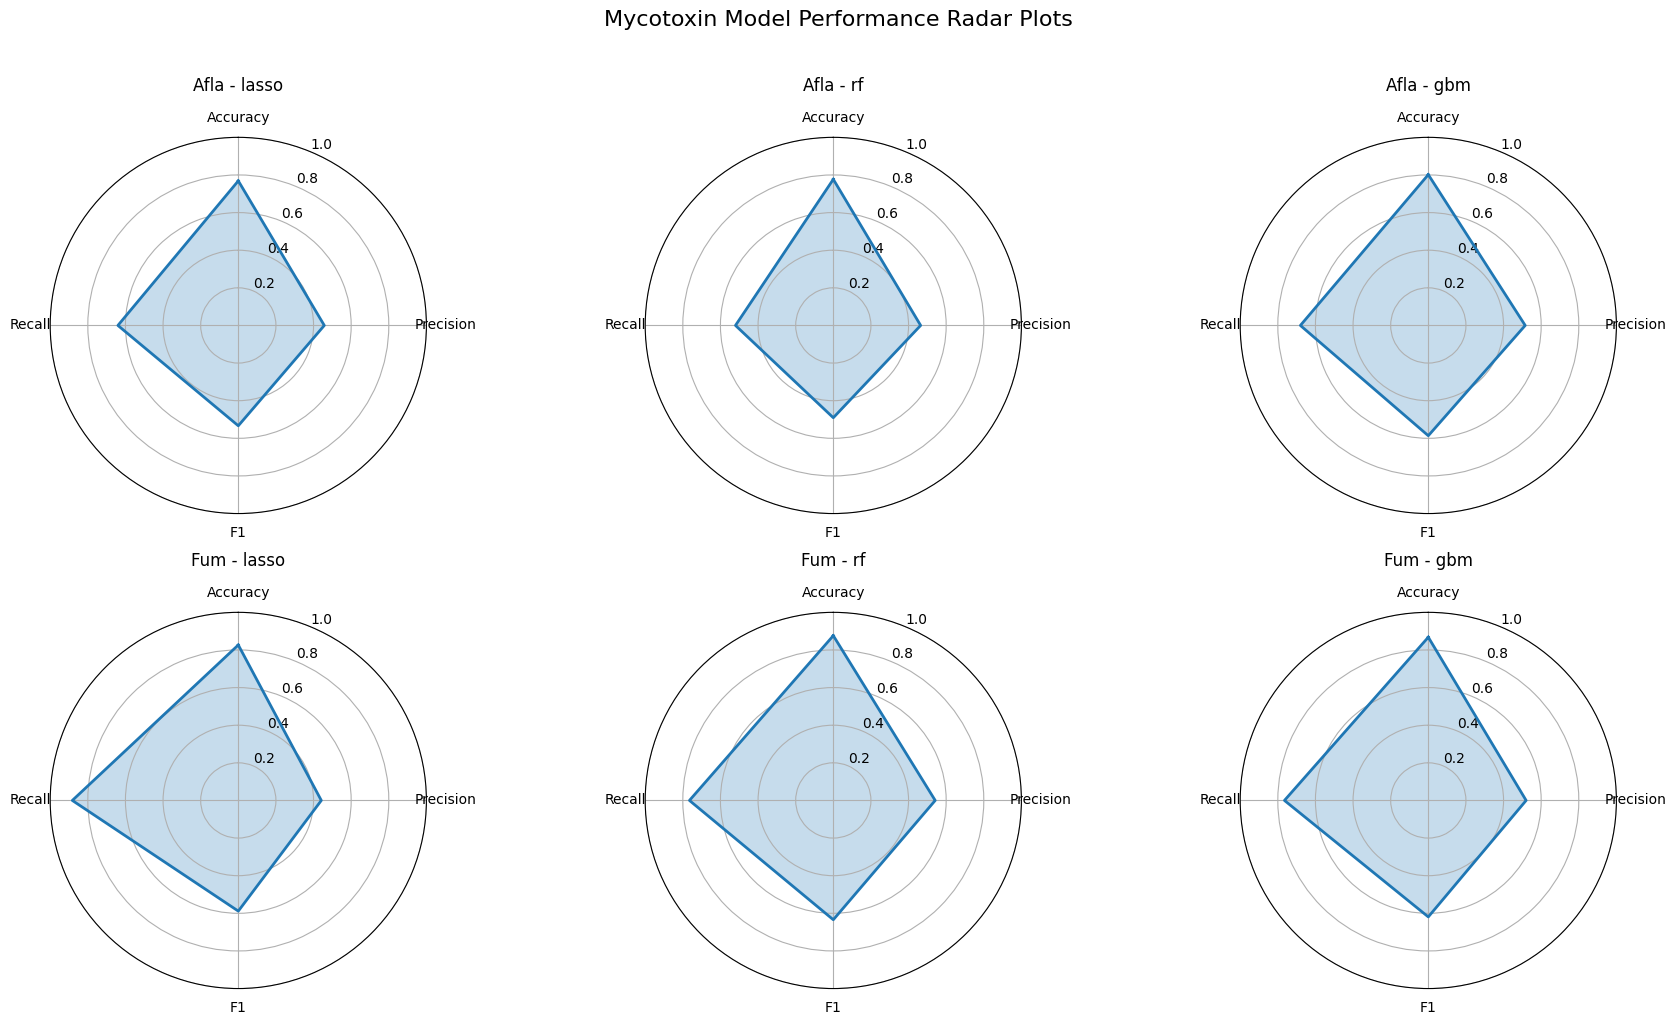

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load the dataset
dfg = pd.read_csv('/content/2024pg.csv')

# Convert dates
dfg['Harvestdate'] = pd.to_datetime(dfg['Harvestdate'])
dfg['Sowdate'] = pd.to_datetime(dfg['Sowdate'])

# Define targets and thresholds
targets = {
    'Afla': 10,
    'Fum': 4000
}

# Clip targets at maximum thresholds
for target_name, threshold in targets.items():
    dfg[target_name] = dfg[target_name].clip(upper=threshold)

# Features
x = dfg.iloc[:, 23:].astype(float)  # adjust columns if needed

# Scale features
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

# Save processed data for later use
np.save('x_scaled.npy', x_scaled)
dfg.to_csv('dfg_processed.csv', index=False)

# Function to generate train/test splits for a given target
def prepare_target(y_column, x_scaled):
    y = np.where(dfg[y_column] >= targets[y_column], 1, 0)
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y, test_size=0.2, random_state=42
    )

    # Handle imbalance using SMOTE
    sm = SMOTE(random_state=42)
    x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

    # Scale again after resampling
    scaler = StandardScaler()
    scaler.fit(x_train_res)
    x_train_res = scaler.transform(x_train_res)
    x_test_scaled = scaler.transform(x_test)

    return x_train_res, x_test_scaled, y_train_res, y_test

# Example usage:
# x_train_afla, x_test_afla, y_train_afla, y_test_afla = prepare_target('Afla', x_scaled)
# x_train_fum, x_test_fum, y_train_fum, y_test_fum = prepare_target('Fum', x_scaled)

# model_training_and_radar.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import your trained model functions
from __main__ import train_Lcmodel, train_Rcmodel, train_Gcmodel

# Rename the list of target names to avoid overwriting the 'targets' dictionary
target_names = ['Afla', 'Fum']
models_eval = {'lasso': train_Lcmodel, 'rf': train_Rcmodel, 'gbm': train_Gcmodel}

results_by_target = {}

# Run models for each target
for target_name in target_names: # Iterate over target_names
    print(f"\nRunning models for target: {target_name}")
    x_train, x_test, y_train, y_test = prepare_target(target_name, x_scaled)

    model_results = {}

    for model_name, train_model in models_eval.items():
        result = train_model(x_train, y_train, x_test, y_test)
        model_results[model_name] = result

    # Collect metrics
    metrics_summary = {'Model': [], 'Accuracy': [], 'Precision': [], 'F1': [], 'Recall': []}
    for model_name, result in model_results.items():
        metrics = result[2]  # metrics dict
        metrics_summary['Model'].append(model_name)
        metrics_summary['Accuracy'].append(metrics['Accuracy'])
        metrics_summary['Precision'].append(metrics['Precision'])
        metrics_summary['F1'].append(metrics['F1'])
        metrics_summary['Recall'].append(metrics['Recall'])

    df_summary = pd.DataFrame(metrics_summary)
    results_by_target[target_name] = df_summary
    print(df_summary)

# -------------------------
# Radar plot (2 rows x 3 columns)
# -------------------------
def create_and_save_radar_plots_multi(results_by_target, plot_title):
    metrics = ['Accuracy', 'Precision', 'F1', 'Recall']

    num_models = len(next(iter(results_by_target.values())))
    num_targets = len(results_by_target)

    fig, axes = plt.subplots(num_targets, num_models, figsize=(6*num_models, 5*num_targets), subplot_kw=dict(polar=True))

    # Adjust axes assignment for single target case
    if num_targets == 1:
        # If there's only one target, axes will be a 1D array of subplots
        axes_flattened = axes
        axes = np.empty((1, num_models), dtype=object)
        axes[0, :] = axes_flattened
    elif num_models == 1:
        # If there's only one model, axes will be a 1D array of subplots
        axes_flattened = axes
        axes = np.empty((num_targets, 1), dtype=object)
        axes[:, 0] = axes_flattened

    for i, (target_name, df_metrics) in enumerate(results_by_target.items()):
        df_metrics = df_metrics.set_index('Model')
        model_names = df_metrics.index.tolist()

        for j, model_name in enumerate(model_names):
            ax = axes[i, j]

            values = df_metrics.loc[model_name, metrics].tolist()
            values += values[:1]  # close loop

            angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
            angles += angles[:1]

            ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name)
            ax.fill(angles, values, alpha=0.25)

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(metrics)
            ax.set_ylim(0, 1)

            ax.set_theta_offset(np.pi/2)
            ax.set_theta_direction(-1)
            ax.set_title(f'{target_name} - {model_name}', y=1.1)

    plt.suptitle(plot_title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('radar_plots_mycotoxins.png')
    plt.show()

# Create radar plots
create_and_save_radar_plots_multi(results_by_target, "Mycotoxin Model Performance Radar Plots")